# Sequence Models for ICU Mortality Prediction
- Dataset: https://www.kaggle.com/datasets/msafi04/predict-mortality-of-icu-patients-physionet?select=set-a
- Sequence Models Purpose: This dataset contains step-by-step data points over a period of time. This means features in one time step might affect the features in the next time step. We want to model this change and predict the final feature set based on a series of input feature series. 
- Framework: pytorch


## Model structues

- Standard RNN: hidden state uses tanh at each time step and output layer uses sigmoid.
- LSTM: sigmoid input, forget, output gates with tanh state updates. output layer uses sigmoid.
- GRU: sigmoid update, reset gates with tanh hidden state. output layer uses sigmoid.

- Primary metric: AURPCR (Standard for imbalanced datsets)
- Secondary metrics: F1, accuracy, loss, and AUROC
- Performance is reported on both the validation set and the test set.


In [12]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, average_precision_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# setting seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# device and data constants
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = Path("sequence_data")
SET_A_DIR = DATA_DIR / "set-a"
OUTCOMES_PATH = DATA_DIR / "outcomes-a.csv"
MAX_HOURS = 48
STATIC_FEATURES = ["Age", "Gender", "Height", "ICUType", "Weight"]
DYNAMIC_FEATURES = [
    "Albumin", "ALP", "ALT", "AST", "Bilirubin", "BUN", "Cholesterol", "Creatinine",
    "DiasABP", "FiO2", "GCS", "Glucose", "HCO3", "HCT", "HR", "K", "Lactate",
    "MAP", "MechVent", "Mg", "NIDiasABP", "NIMAP", "NISysABP", "Na", "PaCO2",
    "PaO2", "Platelets", "RespRate", "SaO2", "SysABP", "Temp", "TroponinI",
    "TroponinT", "Urine", "WBC", "pH"
]


In [13]:
def time_to_hour_bucket(time_str, max_hours=MAX_HOURS):
    """Sets the hour bucket for a given time string (e.g., '12:30' -> 12) to simplify time handling."""
    hours, minutes = map(int, time_str.split(":"))
    bucket = hours
    return bucket if 0 <= bucket < max_hours else None


def parse_patient_file(file_path, dynamic_features, static_features, max_hours=MAX_HOURS):
    """Parses a patient file and returns static and dynamic feature arrays."""
    df = pd.read_csv(file_path)
    static_values = {feature: np.nan for feature in static_features}
    hourly_values = np.full((max_hours, len(dynamic_features)), np.nan, dtype=np.float32)
    hourly_masks = np.zeros((max_hours, len(dynamic_features)), dtype=np.float32)
    dynamic_index = {name: idx for idx, name in enumerate(dynamic_features)}

    for _, row in df.iterrows():
        parameter = row["Parameter"]
        value = pd.to_numeric(row["Value"], errors="coerce")
        if pd.isna(value):
            continue

        if parameter in static_values:
            static_values[parameter] = float(value)
            continue

        if parameter not in dynamic_index:
            continue

        bucket = time_to_hour_bucket(row["Time"], max_hours=max_hours)
        if bucket is None:
            continue

        feature_idx = dynamic_index[parameter]
        hourly_values[bucket, feature_idx] = float(value)
        hourly_masks[bucket, feature_idx] = 1.0

    static_array = np.array([static_values[feature] for feature in static_features], dtype=np.float32)
    return {"static": static_array, "values": hourly_values, "masks": hourly_masks}

# loading outcomes
outcomes_df = pd.read_csv(OUTCOMES_PATH)
outcomes_df = outcomes_df[["RecordID", "In-hospital_death"]].copy()
outcomes_df["RecordID"] = outcomes_df["RecordID"].astype(str)
outcomes_df["file_path"] = outcomes_df["RecordID"].apply(lambda rid: SET_A_DIR / f"{rid}.txt")
outcomes_df = outcomes_df[outcomes_df["file_path"].apply(Path.exists)].reset_index(drop=True)

patient_records = {
    row.RecordID: parse_patient_file(row.file_path, DYNAMIC_FEATURES, STATIC_FEATURES)
    for row in outcomes_df.itertuples(index=False)
}

print(f"Patients loaded: {len(patient_records)}")
print(outcomes_df["In-hospital_death"].value_counts())


Patients loaded: 4000
In-hospital_death
0    3446
1     554
Name: count, dtype: int64


In [14]:
# train test splits
train_df, temp_df = train_test_split(
    outcomes_df,
    test_size=0.30,
    stratify=outcomes_df["In-hospital_death"],
    random_state=SEED,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["In-hospital_death"],
    random_state=SEED,
)

for split_name, split_df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(split_name, len(split_df), split_df["In-hospital_death"].mean())

def collect_training_statistics(split_df, patient_records):
    """Collects statistics from training data to use as filler for missing values."""
    train_static = []
    train_dynamic = []
    for record_id in split_df["RecordID"]:
        record = patient_records[record_id]
        train_static.append(record["static"])
        train_dynamic.append(record["values"])

    train_static = np.stack(train_static)
    train_dynamic = np.stack(train_dynamic)

    static_medians = np.nanmedian(train_static, axis=0)
    dynamic_medians = np.nanmedian(train_dynamic.reshape(-1, train_dynamic.shape[-1]), axis=0)

    static_filled = np.where(np.isnan(train_static), static_medians, train_static)
    dynamic_filled = np.where(np.isnan(train_dynamic), dynamic_medians.reshape(1, 1, -1), train_dynamic)

    static_means = static_filled.mean(axis=0)
    static_stds = static_filled.std(axis=0)
    dynamic_means = dynamic_filled.reshape(-1, dynamic_filled.shape[-1]).mean(axis=0)
    dynamic_stds = dynamic_filled.reshape(-1, dynamic_filled.shape[-1]).std(axis=0)

    static_stds = np.where(static_stds < 1e-6, 1.0, static_stds)
    dynamic_stds = np.where(dynamic_stds < 1e-6, 1.0, dynamic_stds)

    return {
        "static_medians": static_medians.astype(np.float32),
        "dynamic_medians": dynamic_medians.astype(np.float32),
        "static_means": static_means.astype(np.float32),
        "static_stds": static_stds.astype(np.float32),
        "dynamic_means": dynamic_means.astype(np.float32),
        "dynamic_stds": dynamic_stds.astype(np.float32),
    }

stats = collect_training_statistics(train_df, patient_records)

def forward_fill_hourly(values, masks):
    """Fills missing hour values."""
    filled = values.copy()
    for feature_idx in range(filled.shape[1]):
        last_value = np.nan
        for hour in range(filled.shape[0]):
            if masks[hour, feature_idx] == 1.0 and not np.isnan(filled[hour, feature_idx]):
                last_value = filled[hour, feature_idx]
            elif not np.isnan(last_value):
                filled[hour, feature_idx] = last_value
    return filled

def build_split_tensors(split_df, patient_records, stats):
    """Builds a normalized split dataset with the forward filled values."""
    sequences = []
    labels = []

    for record_id, label in zip(split_df["RecordID"], split_df["In-hospital_death"]):
        record = patient_records[record_id]
        static = record["static"].copy()
        static = np.where(np.isnan(static), stats["static_medians"], static)
        static = (static - stats["static_means"]) / stats["static_stds"]

        values = record["values"].copy()
        masks = record["masks"].copy()
        values = forward_fill_hourly(values, masks)
        values = np.where(np.isnan(values), stats["dynamic_medians"].reshape(1, -1), values)
        values = (values - stats["dynamic_means"].reshape(1, -1)) / stats["dynamic_stds"].reshape(1, -1)

        static_repeated = np.repeat(static.reshape(1, -1), MAX_HOURS, axis=0)
        features = np.concatenate([values, masks, static_repeated], axis=1)
        sequences.append(features.astype(np.float32))
        labels.append(float(label))

    X = torch.tensor(np.stack(sequences), dtype=torch.float32)
    y = torch.tensor(labels, dtype=torch.float32)
    return X, y


X_train, y_train = build_split_tensors(train_df, patient_records, stats)
X_val, y_val = build_split_tensors(val_df, patient_records, stats)
X_test, y_test = build_split_tensors(test_df, patient_records, stats)

print(X_train.shape, y_train.shape)


train 2800 0.13857142857142857
validation 600 0.13833333333333334
test 600 0.13833333333333334
torch.Size([2800, 48, 77]) torch.Size([2800])


In [15]:
# training setup
BATCH_SIZE = 64
EPOCHS = 20
HIDDEN_DIM = 64
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)
positive_count = y_train.sum().item()
negative_count = len(y_train) - positive_count
pos_weight = torch.tensor([negative_count / max(positive_count, 1.0)], dtype=torch.float32, device=device)


class MortalityRNN(nn.Module):
    """Vanilla RNN model"""
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True, nonlinearity="tanh")
        self.output = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        _, hidden = self.rnn(x)
        return self.output(hidden[-1]).squeeze(1)


class MortalityLSTM(nn.Module):
    """LSTM model"""
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.output = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        return self.output(hidden[-1]).squeeze(1)


class MortalityGRU(nn.Module):
    """GRU model"""
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.output = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        _, hidden = self.gru(x)
        return self.output(hidden[-1]).squeeze(1)

def make_model(model_name, input_dim, hidden_dim=HIDDEN_DIM):
    """Creates necessary model"""
    if model_name == "RNN":
        return MortalityRNN(input_dim, hidden_dim)
    if model_name == "LSTM":
        return MortalityLSTM(input_dim, hidden_dim)
    if model_name == "GRU":
        return MortalityGRU(input_dim, hidden_dim)
    raise ValueError(f"Unknown model: {model_name}")


In [16]:
def evaluate_model(model, data_loader, criterion):
    """All evaluation metrics contained in one function to make it easy to consolidate results."""
    model.eval()
    all_labels = []
    all_probs = []
    total_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            probs = torch.sigmoid(logits)

            total_loss += loss.item() * yb.size(0)
            total_examples += yb.size(0)
            all_labels.extend(yb.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())

    labels = np.array(all_labels)
    probs = np.array(all_probs)
    preds = (probs >= 0.5).astype(int)

    return {
        "loss": total_loss / total_examples,
        "auprc": average_precision_score(labels, probs),
        "auroc": roc_auc_score(labels, probs),
        "f1": f1_score(labels, preds, zero_division=0),
        "accuracy": accuracy_score(labels, preds),
    }


def train_model(model_name, input_dim):
    """Training loop for each model and tracking best performance metric."""
    torch.manual_seed(SEED)
    model = make_model(model_name, input_dim).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"train_loss": [], "val_loss": [], "val_auprc": [], "val_auroc": []}
    best_state = None
    best_val_auprc = -np.inf

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        running_examples = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * yb.size(0)
            running_examples += yb.size(0)

        train_loss = running_loss / running_examples
        val_metrics = evaluate_model(model, val_loader, criterion)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_auprc"].append(val_metrics["auprc"])
        history["val_auroc"].append(val_metrics["auroc"])

        print(
            f"{model_name} Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | val_auprc={val_metrics['auprc']:.4f} | "
            f"val_auroc={val_metrics['auroc']:.4f} | val_f1={val_metrics['f1']:.4f}"
        )

        if val_metrics["auprc"] > best_val_auprc:
            best_val_auprc = val_metrics["auprc"]
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    val_metrics = evaluate_model(model, val_loader, criterion)
    test_metrics = evaluate_model(model, test_loader, criterion)
    return model, history, val_metrics, test_metrics


## Vanilla RNN


In [17]:
rnn_model, rnn_history, rnn_val_metrics, rnn_test_metrics = train_model("RNN", X_train.shape[-1])
rnn_val_metrics, rnn_test_metrics

RNN Epoch 01 | train_loss=1.0372 | val_loss=0.9937 | val_auprc=0.3646 | val_auroc=0.7636 | val_f1=0.3882
RNN Epoch 02 | train_loss=0.8828 | val_loss=0.9392 | val_auprc=0.4372 | val_auroc=0.7957 | val_f1=0.4178
RNN Epoch 03 | train_loss=0.8256 | val_loss=0.9232 | val_auprc=0.4418 | val_auroc=0.8041 | val_f1=0.4164
RNN Epoch 04 | train_loss=0.7815 | val_loss=0.9514 | val_auprc=0.4261 | val_auroc=0.7975 | val_f1=0.4318
RNN Epoch 05 | train_loss=0.7416 | val_loss=0.9046 | val_auprc=0.4627 | val_auroc=0.8202 | val_f1=0.4667
RNN Epoch 06 | train_loss=0.7078 | val_loss=0.9356 | val_auprc=0.4431 | val_auroc=0.8115 | val_f1=0.4403
RNN Epoch 07 | train_loss=0.6596 | val_loss=0.9581 | val_auprc=0.4192 | val_auroc=0.8106 | val_f1=0.4676
RNN Epoch 08 | train_loss=0.6227 | val_loss=1.0262 | val_auprc=0.4106 | val_auroc=0.8057 | val_f1=0.4320
RNN Epoch 09 | train_loss=0.5847 | val_loss=1.1023 | val_auprc=0.4127 | val_auroc=0.7962 | val_f1=0.4242
RNN Epoch 10 | train_loss=0.5360 | val_loss=1.1624 | va

({'loss': 0.9045948219299317,
  'auprc': 0.46269772370089973,
  'auroc': 0.8201626622544336,
  'f1': 0.4666666666666667,
  'accuracy': 0.76},
 {'loss': 0.8345762268702189,
  'auprc': 0.48047375494107397,
  'auroc': 0.8466127566358277,
  'f1': 0.46886446886446886,
  'accuracy': 0.7583333333333333})

## LSTM


In [18]:
lstm_model, lstm_history, lstm_val_metrics, lstm_test_metrics = train_model("LSTM", X_train.shape[-1])
lstm_val_metrics, lstm_test_metrics


LSTM Epoch 01 | train_loss=1.1072 | val_loss=1.0516 | val_auprc=0.3388 | val_auroc=0.7510 | val_f1=0.3789
LSTM Epoch 02 | train_loss=0.9071 | val_loss=0.9662 | val_auprc=0.3854 | val_auroc=0.7825 | val_f1=0.4173
LSTM Epoch 03 | train_loss=0.7850 | val_loss=0.9400 | val_auprc=0.4173 | val_auroc=0.7971 | val_f1=0.4188
LSTM Epoch 04 | train_loss=0.6814 | val_loss=0.9969 | val_auprc=0.4242 | val_auroc=0.8047 | val_f1=0.4351
LSTM Epoch 05 | train_loss=0.6008 | val_loss=0.9904 | val_auprc=0.4330 | val_auroc=0.8030 | val_f1=0.4270
LSTM Epoch 06 | train_loss=0.5442 | val_loss=1.0152 | val_auprc=0.4479 | val_auroc=0.7976 | val_f1=0.4101
LSTM Epoch 07 | train_loss=0.4913 | val_loss=1.1668 | val_auprc=0.4255 | val_auroc=0.7935 | val_f1=0.4359
LSTM Epoch 08 | train_loss=0.4439 | val_loss=1.1969 | val_auprc=0.4482 | val_auroc=0.7874 | val_f1=0.4132
LSTM Epoch 09 | train_loss=0.3832 | val_loss=1.2043 | val_auprc=0.4479 | val_auroc=0.8008 | val_f1=0.4407
LSTM Epoch 10 | train_loss=0.3402 | val_loss=1

({'loss': 1.1968869932492574,
  'auprc': 0.44817351141171197,
  'auroc': 0.7873971708885833,
  'f1': 0.4132231404958678,
  'accuracy': 0.7633333333333333},
 {'loss': 0.9295173056920369,
  'auprc': 0.4956289405149148,
  'auroc': 0.8402041434597189,
  'f1': 0.4627450980392157,
  'accuracy': 0.7716666666666666})

## GRU


In [19]:
gru_model, gru_history, gru_val_metrics, gru_test_metrics = train_model("GRU", X_train.shape[-1])
gru_val_metrics, gru_test_metrics


GRU Epoch 01 | train_loss=1.0814 | val_loss=1.0053 | val_auprc=0.3604 | val_auroc=0.7633 | val_f1=0.3623
GRU Epoch 02 | train_loss=0.9032 | val_loss=0.9376 | val_auprc=0.4185 | val_auroc=0.7950 | val_f1=0.4070
GRU Epoch 03 | train_loss=0.8167 | val_loss=0.9363 | val_auprc=0.4343 | val_auroc=0.8060 | val_f1=0.4275
GRU Epoch 04 | train_loss=0.7639 | val_loss=0.9366 | val_auprc=0.4296 | val_auroc=0.8064 | val_f1=0.4176
GRU Epoch 05 | train_loss=0.7039 | val_loss=0.9330 | val_auprc=0.4231 | val_auroc=0.8079 | val_f1=0.4255
GRU Epoch 06 | train_loss=0.6537 | val_loss=0.9913 | val_auprc=0.4113 | val_auroc=0.8082 | val_f1=0.4262
GRU Epoch 07 | train_loss=0.6001 | val_loss=1.0244 | val_auprc=0.4204 | val_auroc=0.8104 | val_f1=0.4238
GRU Epoch 08 | train_loss=0.5931 | val_loss=1.0150 | val_auprc=0.4337 | val_auroc=0.7994 | val_f1=0.4264
GRU Epoch 09 | train_loss=0.5182 | val_loss=1.0632 | val_auprc=0.4250 | val_auroc=0.8041 | val_f1=0.4427
GRU Epoch 10 | train_loss=0.4661 | val_loss=1.1532 | va

({'loss': 1.1532423996925354,
  'auprc': 0.4344384237991487,
  'auroc': 0.8021952413134161,
  'f1': 0.43478260869565216,
  'accuracy': 0.7833333333333333},
 {'loss': 0.9050317327181499,
  'auprc': 0.49372266273074317,
  'auroc': 0.8546526531658549,
  'f1': 0.49382716049382713,
  'accuracy': 0.795})

## Comparison Table


In [20]:
comparison_df = pd.DataFrame([
    {"model": "RNN", "split": "validation", **rnn_val_metrics},
    {"model": "RNN", "split": "test", **rnn_test_metrics},
    {"model": "LSTM", "split": "validation", **lstm_val_metrics},
    {"model": "LSTM", "split": "test", **lstm_test_metrics},
    {"model": "GRU", "split": "validation", **gru_val_metrics},
    {"model": "GRU", "split": "test", **gru_test_metrics},
])
comparison_df


,model,split,loss,auprc,auroc,f1,accuracy
0,RNN,validation,0.904595,0.462698,0.820163,0.466667,0.760000
1,RNN,test,0.834576,0.480474,0.846613,0.468864,0.758333
2,LSTM,validation,1.196887,0.448174,0.787397,0.413223,0.763333
3,LSTM,test,0.929517,0.495629,0.840204,0.462745,0.771667
4,GRU,validation,1.153242,0.434438,0.802195,0.434783,0.783333
5,GRU,test,0.905032,0.493723,0.854653,0.493827,0.795000


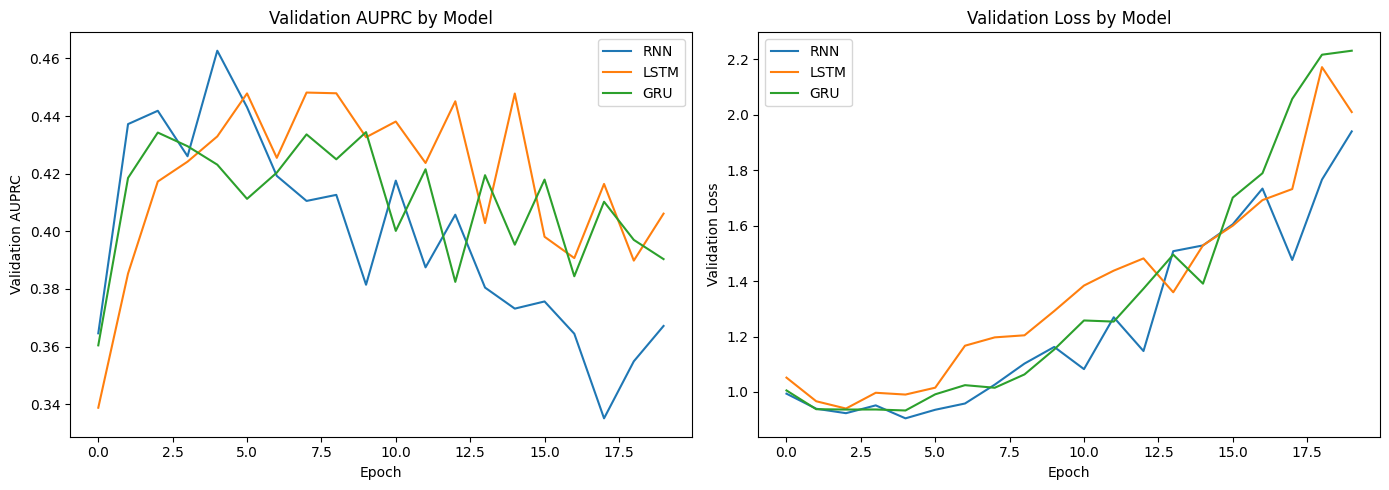

In [21]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(rnn_history["val_auprc"], label="RNN")
plt.plot(lstm_history["val_auprc"], label="LSTM")
plt.plot(gru_history["val_auprc"], label="GRU")
plt.xlabel("Epoch")
plt.ylabel("Validation AUPRC")
plt.title("Validation AUPRC by Model")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(rnn_history["val_loss"], label="RNN")
plt.plot(lstm_history["val_loss"], label="LSTM")
plt.plot(gru_history["val_loss"], label="GRU")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss by Model")
plt.legend()

plt.tight_layout()
plt.show()


### Major Differences
- Based on the results there are no major differences between the three model types. 
- RNN had the best AUPCR.
- LSTM had the best test AUPCR
- GRU had the best test AUROC, test F1, and accuracy. 
- As no model fully dominated on a single or number of metrics, the differences in the model architecture doesn't seem to matter too much in this problem. The main differentiator is probably the numerical problem definition and feature engineering. 
- The LSTM has a more complex memory handling than the RNN but that didnt seem to make much of a difference, probably because the dataset is not large enough for the architecture to maximize the memory complexity. 
- The GRU serves as a simpler LSTM but a more complex RNN. It has fewer logic gates than the LSTM but more than the RNN. It seems to be balancing the generalization based on our results. 
- All the models seem to be overfitting, probably because of validation data size.

## Part 3: feed forward network? 
- yes you can use a feed forward but only if you changed the problem setup. We would convert the original patient time series data into a fixed length vector using the summary statistics we collected earlier. This would allow us to fill missing data indexes and end up with one vector per patient. This allows us to collapse all of the patient's history into a set of definite, static attributes. Now these serve as data points for our feed-forward network to predict if a given patient array results in death or surival. 

# Word Embeddings

### Why Word2Vec
- Simple to implement with gensim
- Lightweight and fast to load compared with transformer-based models like BERT
- Produces dense vector embeddings where semantically similar words tend to have similar vectors
- Easy to use for direct word lookup, similarity scoring, and visualization
- Cosine similarity and Euclidean distance are straightforward to compute on Word2Vec vectors
- Easier to explain than FastText, GloVe, or BERT in a notebook assignment


In [22]:
from pathlib import Path
import re
from difflib import get_close_matches
import numpy as np
import gensim.downloader as api
from gensim.models import KeyedVectors


def load_word2vec_model(local_path=None, model_name="word2vec-google-news-300", limit=None):
    """load model"""
    if local_path:
        local_path = Path(local_path)
        binary = local_path.suffix == ".bin"
        print(f"Loading local Word2Vec vectors from {local_path}...")
        model = KeyedVectors.load_word2vec_format(local_path, binary=binary, limit=limit)
    else:
        print(f"Loading '{model_name}' from gensim-data cache.")
        model = api.load(model_name)
    print(f"Loaded {len(model):,} tokens with vector size {model.vector_size}.")
    return model


def get_embedding(word, model):
    if word in model:
        return model[word], "exact"

    normalized_forms = [
        word.lower(),
        re.sub(r"[^A-Za-z0-9]+", "", word.lower()),
    ]
    for candidate in normalized_forms:
        if candidate and candidate in model:
            return model[candidate], f"normalized:{candidate}"

    pieces = [piece for piece in re.split(r"[-_\s]+", word.lower()) if piece]
    known_pieces = [model[piece] for piece in pieces if piece in model]
    if known_pieces:
        return np.mean(known_pieces, axis=0), f"piece-average:{pieces}"

    suggestions = get_close_matches(word.lower(), model.index_to_key[:50000], n=5, cutoff=0.75)
    return None, suggestions

# use from gensim cache
word2vec_model = load_word2vec_model()


Loading 'word2vec-google-news-300' from gensim-data cache.
Loaded 3,000,000 tokens with vector size 300.


In [23]:
word_1 = input("first: ").strip()
word_2 = input("second: ").strip()

for label, word in [("Word 1", word_1), ("Word 2", word_2)]:
    embedding, status = get_embedding(word, word2vec_model)
    print(f"\n{label}: {word}")
    if embedding is not None:
        print(f"Lookup status: {status}")
        print(f"Embedding shape: {embedding.shape}")
        print("First 10 values:", embedding[:10])
    else:
        print("Out of vocabulary.")
        if status:
            print("Closest suggestions:", status)


Word 1: king
Lookup status: exact
Embedding shape: (300,)
First 10 values: [ 0.12597656  0.02978516  0.00860596  0.13964844 -0.02563477 -0.03613281
  0.11181641 -0.19824219  0.05126953  0.36328125]

Word 2: queen
Lookup status: exact
Embedding shape: (300,)
First 10 values: [ 0.00524902 -0.14355469 -0.06933594  0.12353516  0.13183594 -0.08886719
 -0.07128906 -0.21679688 -0.19726562  0.05566406]


### approx suggestions
- lowercase the word, remove punctuation, average embeddings of known sub-words
- fuzzy typo fixing


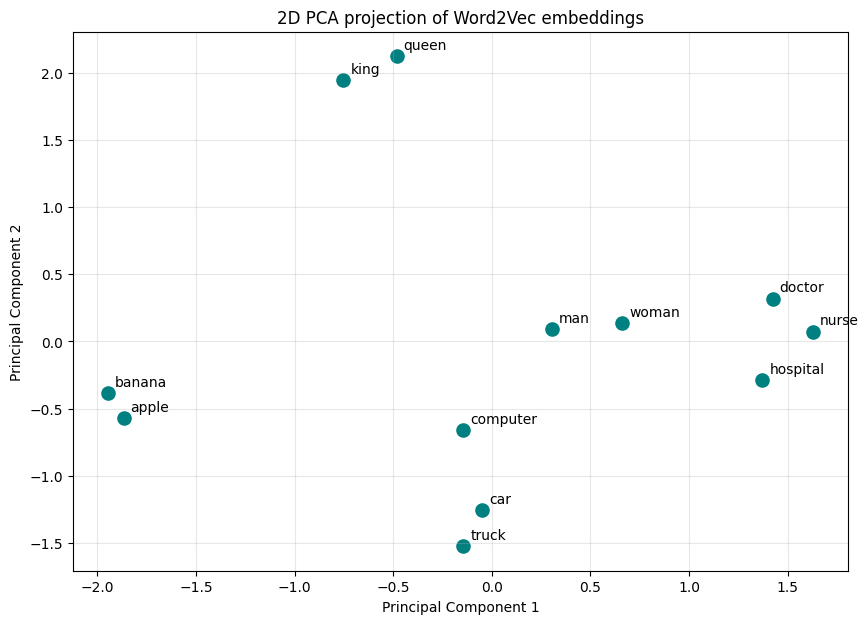

In [24]:
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt


def plot_words_2d(words, model):
    valid_words = []
    vectors = []

    for word in words:
        embedding, _ = get_embedding(word, model)
        valid_words.append(word)
        vectors.append(embedding)

    reduced_vectors = PCA(n_components=2).fit_transform(np.array(vectors))

    plt.figure(figsize=(10, 7))
    plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1], s=90, color="teal")

    for index, word in enumerate(valid_words):
        plt.annotate(word, (reduced_vectors[index, 0], reduced_vectors[index, 1]), xytext=(5, 5), textcoords="offset points")

    plt.title("2D PCA projection of Word2Vec embeddings")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(alpha=0.3)
    plt.show()


words_to_plot = [
    "king", "queen", "man", "woman", "doctor", "nurse",
    "hospital", "apple", "banana", "car", "truck", "computer"
]

plot_words_2d(words_to_plot, word2vec_model)


### Cosine similarity for word embeddings
- standard to compare two vectors
- comparing direction instead of magnitude
- vectors pointint in the same direction more likeley to be similar

### Euclidean distance dissimilarity for word embeddings
- euclidean distance measures the distance between two vectors
- if two vectors are similar, they are closer thus euclidean distance is small
- if they are different, they are further thus euclidean distance is large
- cosine sim only checks if two vectors point in the same direction but euclidean distance also shows how far they are in the space

In [25]:
import pandas as pd

def cosine_similarity(vec_a, vec_b):
    vec_a = np.asarray(vec_a)
    vec_b = np.asarray(vec_b)
    denominator = np.linalg.norm(vec_a) * np.linalg.norm(vec_b)
    if denominator == 0:
        raise ValueError("undefined")
    return float(np.dot(vec_a, vec_b) / denominator)


def euclidean_distance(vec_a, vec_b):
    vec_a = np.asarray(vec_a)
    vec_b = np.asarray(vec_b)
    return float(np.linalg.norm(vec_a - vec_b))


def score_embeddings(vec_a, vec_b, metric="cosine"):
    metric = metric.lower()
    if metric == "cosine":
        return cosine_similarity(vec_a, vec_b)
    if metric in {"euclidean", "euclidian", "distance"}:
        return euclidean_distance(vec_a, vec_b)
    raise ValueError("metric must be 'cosine' or 'euclidean'")


def similarity_for_pair(word_a, word_b, model, metric="cosine"):
    embedding_a, status_a = get_embedding(word_a, model)
    embedding_b, status_b = get_embedding(word_b, model)

    if embedding_a is None or embedding_b is None:
        return {
            "word_a": word_a,
            "word_b": word_b,
            "status_a": status_a,
            "status_b": status_b,
            "metric": metric,
            "score": None,
        }

    return {
        "word_a": word_a,
        "word_b": word_b,
        "status_a": status_a,
        "status_b": status_b,
        "metric": metric,
        "score": score_embeddings(embedding_a, embedding_b, metric=metric),
    }


def batch_similarity(word_pairs, model, metric="cosine"):
    return pd.DataFrame([
        similarity_for_pair(word_a, word_b, model, metric=metric)
        for word_a, word_b in word_pairs
    ])


def rank_words_against_query(query_word, candidate_words, model, metric="cosine"):
    query_embedding, query_status = get_embedding(query_word, model)
    if query_embedding is None:
        raise ValueError(f"Query word {query_word!r} is OOV. Status: {query_status}")

    rows = []
    for candidate in candidate_words:
        candidate_embedding, candidate_status = get_embedding(candidate, model)
        if candidate_embedding is None:
            rows.append({
                "query_word": query_word,
                "candidate_word": candidate,
                "candidate_status": candidate_status,
                "metric": metric,
                "score": None,
            })
            continue

        rows.append({
            "query_word": query_word,
            "candidate_word": candidate,
            "candidate_status": candidate_status,
            "metric": metric,
            "score": score_embeddings(query_embedding, candidate_embedding, metric=metric),
        })

    ranking_df = pd.DataFrame(rows)
    ascending = metric in {"euclidean", "euclidian", "distance"}
    return ranking_df.sort_values("score", ascending=ascending, na_position="last").reset_index(drop=True)


In [27]:
metric_choice = input("Choose a metric: cosine or euclidean: ").strip().lower() or "cosine"

raw_pairs = input(
    "Enter word pairs separated by commas (example: king queen, doctor nurse, king banana): "
).strip()

word_pairs = []
for pair_text in raw_pairs.split(","):
    parts = pair_text.strip().split()
    if len(parts) == 2:
        word_pairs.append((parts[0], parts[1]))

similarity_df = batch_similarity(word_pairs, word2vec_model, metric=metric_choice)
similarity_df


,word_a,word_b,status_a,status_b,metric,score
0,king,king,exact,exact,cosine,1.0
1,queen,queen,exact,exact,cosine,1.0


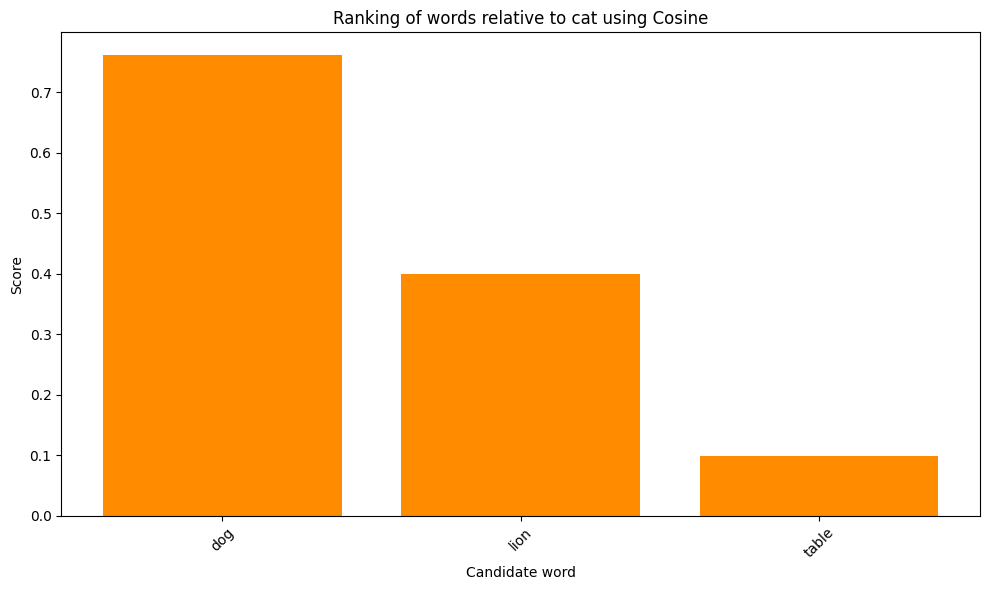

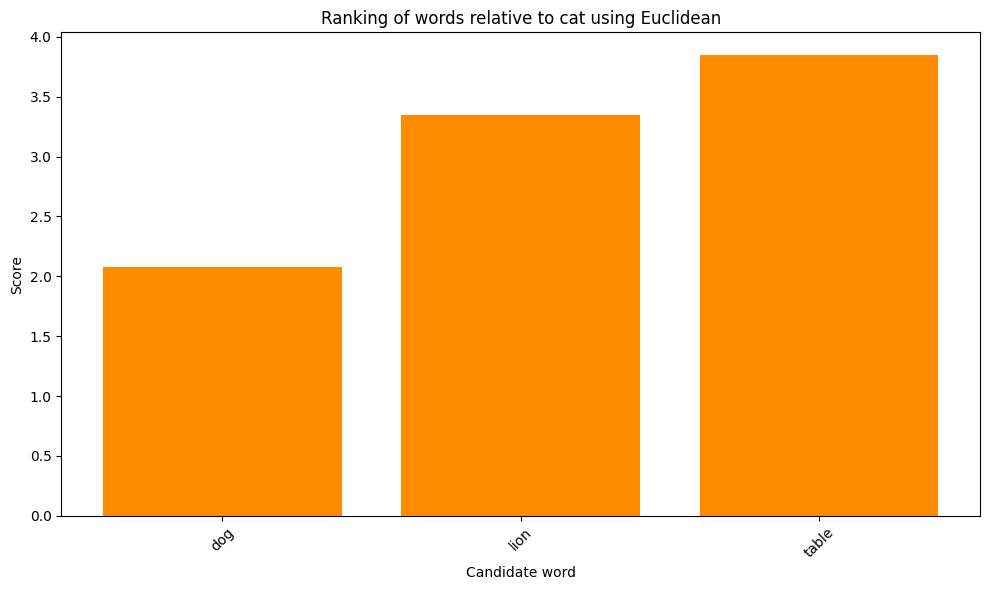

,query_word,candidate_word,candidate_status,metric,score
0,cat,dog,exact,cosine,0.760946
1,cat,lion,exact,cosine,0.399773
2,cat,table,exact,cosine,0.099596


,query_word,candidate_word,candidate_status,metric,score
0,cat,dog,exact,euclidean,2.081534
1,cat,lion,exact,euclidean,3.345014
2,cat,table,exact,euclidean,3.845554


In [28]:
def plot_word_ranking(query_word, candidate_words, model, metric="cosine"):
    ranking_df = rank_words_against_query(query_word, candidate_words, model, metric=metric)
    ranking_df = ranking_df.dropna(subset=["score"])

    plt.figure(figsize=(10, 6))
    plt.bar(ranking_df["candidate_word"], ranking_df["score"], color="darkorange")
    plt.title(f"Ranking of words relative to {query_word} using {metric.title()}")
    plt.xlabel("Candidate word")
    plt.ylabel("Score")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return ranking_df


query_word = "cat"
candidate_words = ["dog", "lion", "table"]

cosine_ranking = plot_word_ranking(query_word, candidate_words, word2vec_model, metric="cosine")
euclidean_ranking = plot_word_ranking(query_word, candidate_words, word2vec_model, metric="euclidean")

display(cosine_ranking)
display(euclidean_ranking)


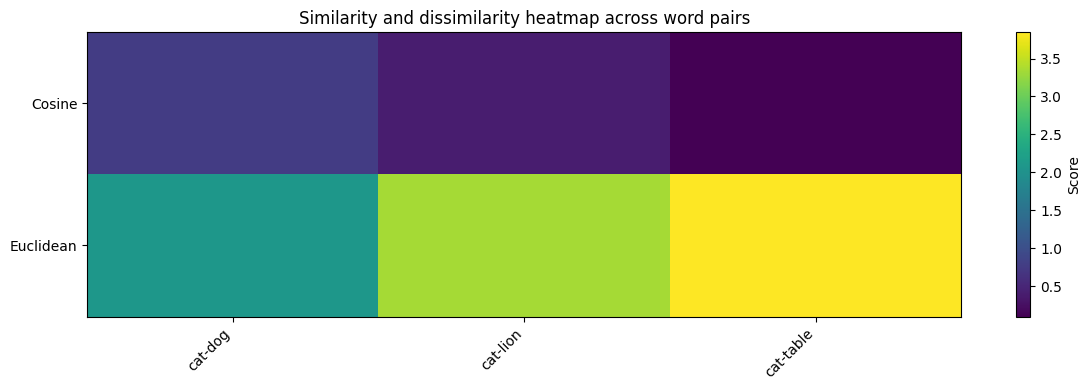

,cat-dog,cat-lion,cat-table
cosine,0.760946,0.399773,0.099596
euclidean,2.081534,3.345014,3.845554


In [29]:
def build_pair_score_heatmap(word_pairs, model, metrics=("cosine", "euclidean")):
    metric_labels = []
    matrix_rows = []

    for metric in metrics:
        scores = []
        for word_a, word_b in word_pairs:
            result = similarity_for_pair(word_a, word_b, model, metric=metric)
            scores.append(result["score"] if result["score"] is not None else np.nan)
        metric_labels.append(metric)
        matrix_rows.append(scores)

    heatmap_matrix = np.array(matrix_rows, dtype=float)
    pair_labels = [f"{word_a}-{word_b}" for word_a, word_b in word_pairs]

    plt.figure(figsize=(12, 4))
    image = plt.imshow(heatmap_matrix, cmap="viridis", aspect="auto")
    plt.colorbar(image, label="Score")
    plt.xticks(range(len(pair_labels)), pair_labels, rotation=45, ha="right")
    plt.yticks(range(len(metric_labels)), [label.title() for label in metric_labels])
    plt.title("Similarity and dissimilarity heatmap across word pairs")
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(heatmap_matrix, index=metric_labels, columns=pair_labels)


heatmap_pairs = [
    ("cat", "dog"),
    ("cat", "lion"),
    ("cat", "table")
]

heatmap_df = build_pair_score_heatmap(heatmap_pairs, word2vec_model)
heatmap_df
